# Example of running power flows for a scenario
This requires the save file from running 'scenario_example.ipynb' which has a network model and results from energy optimisation. This file will be first loaded to give our scenario


In [1]:
# import sys
# sys.path.append("../") # go to parent dir
import echo.echo_scenario as ecs

file_name = '../data/test_scenario2.pickle'

scenario = ecs.EchoScenario(load_file=file_name)

Importing network data
Finished importing network data


# Run the power flows
Next we will run the power flows, current a single power factor can be set for all sites. A save file name can also be specified to save the results automatically. This should be a '.pickle' file. Additionally, the file will be compressed using lzma.

In [2]:
power_factor = 0.93
save_file_name = '../data/power_flow_results.pickle'
power_flow_results = scenario.run_power_flows(power_factor=power_factor, save_pickle_file=save_file_name)

Running power flows: 100%|██████████| 672/672 [04:52<00:00,  2.29it/s]


# Print progress to file instead of terminal
To print progress to file instead of screen use the optional input log_file

e.g.

power_flow_results = scenario.run_power_flows(power_factor=power_factor, save_pickle_file=save_file_name, log_file = 'progress_log.txt')

# Having a look at some of the results
The results are output as a dictionary of pandas dataframes. The data frames are:
- status: list of true false for whether the power flow converged
- power_inbalance: inbalance between total generation, total losses, and total loads
- bus_voltage
- branch_power_0: power at end 0 of branch
- branch_power_1: power at end 1 of branch
- branch_current_0: current at end 0 of branch
- branch_current_1: current at end 1 of branch
- transformer_names: a list of the names of all transformers, note that within the dataframes these names would be appended with the phase (_A, _B, _C)

Branches include lines and transformers. To get just the transformers look for the columns that contain the transformer names.

Positive power at an end represents power injected into the branch, and negative represents power leaving the branch. For example, to work out power losses in a branch you would sum the power at end 0 and end 1.

In [3]:
power_flow_results.keys()

dict_keys(['status', 'bus_voltage', 'branch_power_0', 'branch_power_1', 'branch_current_0', 'branch_current_1', 'transformer_names', 'power_inbalance', 'total_generation', 'total_loss', 'total_zip'])

# Check if the power flow calculations converged

In [4]:
import numpy as np
print('Number of timesteps for which the power flow converged was {}'.format(np.array(power_flow_results['status']).sum()))
print('Number of timesteps for which the power flow did not converged was {}'.format(len(power_flow_results['status']) - np.array(power_flow_results['status']).sum()))

Number of timesteps for which the power flow converged was 672
Number of timesteps for which the power flow did not converged was 0


In [5]:
power_flow_results['bus_voltage'].head()

,node_1.A,node_1.B,node_1.C,node_10.A,node_10.B,node_10.C,node_100.A,node_100.B,node_100.C,node_1000.A,...,node_994.C,node_995.A,node_995.B,node_995.C,node_996.B,node_997.A,node_998.A,node_998.B,node_998.C,node_999.A
0,0.995455,0.995455,0.995455,0.947251,0.947608,0.948205,0.946087,0.944541,0.947428,0.947725,...,0.972067,0.948363,0.949368,0.974553,0.948397,0.946867,0.948982,0.952900,0.973988,0.948021
1,0.995455,0.995455,0.995455,0.948288,0.948627,0.949205,0.947146,0.945621,0.948441,0.948675,...,0.972525,0.949301,0.950283,0.974963,0.949332,0.947834,0.949907,0.953745,0.974410,0.948965
2,0.995455,0.995455,0.995455,0.942773,0.943211,0.943899,0.941515,0.939883,0.943061,0.943663,...,0.970110,0.944354,0.945454,0.972800,0.944401,0.942731,0.945026,0.949285,0.972186,0.943984
3,0.995455,0.995455,0.995455,0.947770,0.948118,0.948706,0.946617,0.945082,0.947935,0.948201,...,0.972296,0.948832,0.949826,0.974758,0.948865,0.947351,0.949445,0.953323,0.974199,0.948493
4,0.995455,0.995455,0.995455,0.945421,0.945810,0.946444,0.944218,0.942636,0.945641,0.946058,...,0.971263,0.946717,0.947761,0.973833,0.946756,0.945169,0.947358,0.951416,0.973248,0.946364


# Get minimum and maximum voltage (PU)

In [6]:
print('max voltage was {} (pu)'.format(power_flow_results['bus_voltage'].max().max()))
print('min voltage was {} (pu)'.format(power_flow_results['bus_voltage'].min().min()))

max voltage was 1.043779369966357 (pu)
min voltage was 0.6560392898442606 (pu)


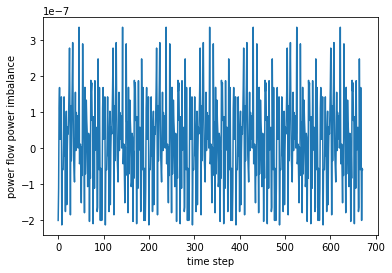

In [7]:
import matplotlib.pyplot as plt
plt.plot(power_flow_results['power_inbalance'])
plt.xlabel('time step')
plt.ylabel('power flow power imbalance')
plt.show()